# Lab 05 — Unsupervised learning II: anomaly detection and limited labels

*Learn when labels are absent, rare, or expensive*

**Goal.** Score an anomaly ranking with labels that were never shown to the model, then simulate two ways of coping with few labels: self-training and active learning.

**Data.** `all_datasets/credit_card_fraud_dataset.csv`, `all_datasets/breast_cancer_dataset.csv`

**Reading.** Chapter 18 (Anomaly Detection) and Chapter 19 (Semi-Supervised and Active Learning)

**Run.** Open a terminal in the course folder, run `cd all_experiments` and `jupyter lab`, open this notebook, and choose **Restart Kernel and Run All Cells**.

**Evidence.** `results/lab05/` — metrics table, top-ranked transactions, label-efficiency curve, figures

**How much is scaffolded?** Fully worked. In Part A the fraud labels are used only to score the ranking. In Part B the test set stays closed until both labelling policies are finished.

**Workflow**

1. Part A — Isolation Forest fraud ranking
2. Part B — Self-training and active learning with few labels
3. Try it yourself, with one solution

## Setup

Imports and paths. Notebooks run from `all_experiments/`, so the course folder is one level up; figures and tables go to `results/lab05/`.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.ensemble import IsolationForest
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, average_precision_score, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.semi_supervised import SelfTrainingClassifier

PROJECT_ROOT = Path.cwd().parent
DATA = PROJECT_ROOT / "all_datasets"

RESULTS = PROJECT_ROOT / "results" / "lab05"
RESULTS.mkdir(parents=True, exist_ok=True)
print("course folder:", PROJECT_ROOT.name)

course folder: MACHINE LEARNING


## Part A — Isolation Forest fraud ranking

Ten thousand card transactions, of which about 1.5% are fraud. An Isolation Forest never sees the `is_fraud` column: it builds random trees and scores each transaction by how quickly it can be isolated from the rest. Unusual rows are isolated in a few splits; ordinary rows take many. The labels are held back and used only to judge the ranking afterwards.

In [2]:
fraud = pd.read_csv(DATA / "credit_card_fraud_dataset.csv")
print(fraud.head())

feature_cols = [
    "amount", "transaction_hour", "foreign_transaction", "location_mismatch",
    "device_trust_score", "velocity_last_24h", "cardholder_age",
]
X = fraud[feature_cols]
y = fraud["is_fraud"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

forest = IsolationForest(n_estimators=300, contamination="auto", random_state=42, n_jobs=-1)
forest.fit(X_train)                                   # no labels passed
anomaly_score = -forest.decision_function(X_test)     # higher = more unusual

   transaction_id  amount  transaction_hour merchant_category  \
0               1   84.47                22       Electronics   
1               2  541.82                 3            Travel   
2               3  237.01                17           Grocery   
3               4  164.33                 4           Grocery   
4               5   30.53                15              Food   

   foreign_transaction  location_mismatch  device_trust_score  \
0                    0                  0                  66   
1                    1                  0                  87   
2                    0                  0                  49   
3                    0                  1                  72   
4                    0                  0                  79   

   velocity_last_24h  cardholder_age  is_fraud  
0                  3              40         0  
1                  1              64         0  
2                  1              61         0  
3                  3  

Two summary numbers, then the one that matters in practice. ROC AUC judges the whole ranking. Average precision focuses on the rare positive class and is far more demanding when only 1.5% of rows are positive. An analyst, though, will only ever look at the top of the list, so precision among the top 100 is the operational number.

In [3]:
prevalence = y_test.mean()
ap = average_precision_score(y_test, anomaly_score)
print("fraud prevalence:", round(prevalence, 4))
print("ROC AUC:", round(roc_auc_score(y_test, anomaly_score), 4))
print("average precision:", round(ap, 4), " (", round(ap / prevalence, 1), "x prevalence)")

ranked = X_test.copy()
ranked["fraud_label"] = y_test.to_numpy()
ranked["anomaly_score"] = anomaly_score
ranked = ranked.sort_values("anomaly_score", ascending=False)
review_budget = 100
top_k_precision = ranked.head(review_budget)["fraud_label"].mean()
print(f"fraud found in the top {review_budget}: {top_k_precision:.0%}")
print(ranked[["fraud_label", "anomaly_score", "amount"]].head(10))

fraud prevalence: 0.015
ROC AUC: 0.9518
average precision: 0.2249  ( 15.0 x prevalence)
fraud found in the top 100: 20%
      fraud_label  anomaly_score  amount
6394            0       0.212892  840.89
5883            0       0.168657  978.56
1623            1       0.166446  569.02
522             0       0.165520  630.67
5536            1       0.163377   28.31
9073            0       0.158442  131.05
4642            0       0.155478  351.99
645             1       0.155063  398.17
7166            0       0.154388  353.58
7698            0       0.152780   75.88


Two pictures. On the left, the score distributions of fraud and non-fraud overlap, which is where the false alarms come from. On the right, precision as a function of how many cases are reviewed: the curve every review team should see before choosing a budget.

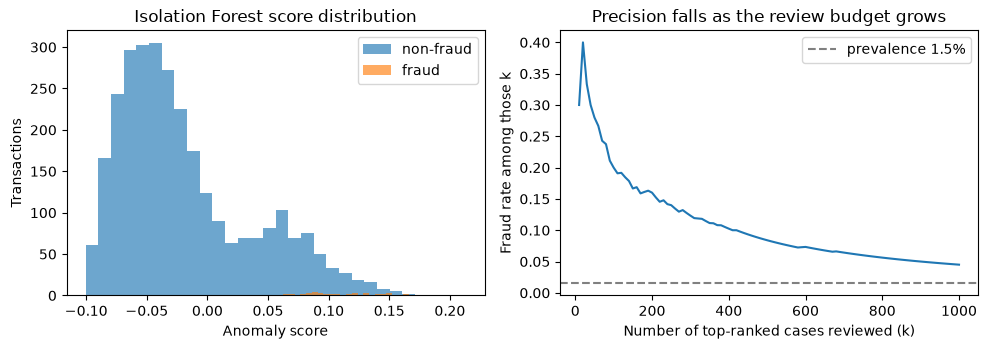

In [4]:
hits = ranked["fraud_label"].to_numpy()
k_values = np.arange(10, 1001, 10)
precision_at_k = [hits[:k].mean() for k in k_values]

fig, axes = plt.subplots(1, 2, figsize=(10, 3.6))
axes[0].hist(anomaly_score[y_test.to_numpy() == 0], bins=30, alpha=0.65, label="non-fraud")
axes[0].hist(anomaly_score[y_test.to_numpy() == 1], bins=30, alpha=0.65, label="fraud")
axes[0].set_xlabel("Anomaly score")
axes[0].set_ylabel("Transactions")
axes[0].set_title("Isolation Forest score distribution")
axes[0].legend()
axes[1].plot(k_values, precision_at_k)
axes[1].axhline(prevalence, linestyle="--", color="grey", label=f"prevalence {prevalence:.1%}")
axes[1].set_xlabel("Number of top-ranked cases reviewed (k)")
axes[1].set_ylabel("Fraud rate among those k")
axes[1].set_title("Precision falls as the review budget grows")
axes[1].legend()
plt.tight_layout()
plt.savefig(RESULTS / "precision_falls_as_the_review_budget_grows.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** Fraud scores sit to the right, but the non-fraud mountain is 65 times taller, so even a small overlap produces many false alarms. That is why ROC AUC looks excellent while precision is modest. The right-hand curve starts high and decays towards the base rate: the first fifty reviews are the most productive, and a team with a fixed budget should read its expected hit rate off this curve.

**What the output shows.** ROC AUC 0.95 looks excellent; average precision 0.22 is the honest number, still fifteen times the 1.5% base rate. Reviewing the top 100 transactions finds 20 frauds, a 20% hit rate, and the precision-at-k curve shows that rate falling steadily as the budget grows. Report precision at the review budget, not the AUC alone.

## Part B — Self-training and active learning with few labels

Now the opposite problem: plenty of rows, but labels are expensive. The breast-cancer data is split three ways. The *pool* is where labels can be bought, the *validation* set judges each policy during development, and the *test* set is sealed until both policies are finished.

In [5]:
rng = np.random.default_rng(42)

cancer = pd.read_csv(DATA / "breast_cancer_dataset.csv")
X_c = cancer.drop(columns=["id", "diagnosis", "Unnamed: 32"], errors="ignore")
y_c = (cancer["diagnosis"] == "M").astype(int).to_numpy()

X_dev, Xc_test, y_dev, yc_test = train_test_split(
    X_c, y_c, test_size=0.25, random_state=42, stratify=y_c
)
X_pool, X_val, y_pool, y_val = train_test_split(
    X_dev, y_dev, test_size=0.25, random_state=7, stratify=y_dev
)
X_pool = X_pool.reset_index(drop=True)
y_pool = np.asarray(y_pool)
print("pool:", len(X_pool), " validation:", len(X_val), " test:", len(Xc_test))

def make_model():
    return Pipeline([
        ("scale", StandardScaler()),
        ("model", LogisticRegression(max_iter=2000)),
    ])

pool: 319  validation: 107  test: 143


Self-training hides 70% of the pool labels (scikit-learn uses $-1$ for “unknown”), fits on the rest, then lets the model label any unlabelled row it is at least 90% sure about and refits. It can help when the confident predictions are right; it can also teach the model its own mistakes.

In [6]:
y_partial = y_pool.copy()
y_partial[rng.random(len(y_partial)) < 0.70] = -1
print("labels kept:", int((y_partial != -1).sum()), "of", len(y_partial))

semi = Pipeline([
    ("scale", StandardScaler()),
    ("model", SelfTrainingClassifier(LogisticRegression(max_iter=2000), threshold=0.90)),
])
semi.fit(X_pool, y_partial)
print("self-training validation accuracy:",
      round(accuracy_score(y_val, semi.predict(X_val)), 3))

labels kept: 89 of 319
self-training validation accuracy: 0.963


Active learning chooses *which* labels to buy. Both policies start from the same 40 labels and buy 15 more per round. Uncertainty sampling asks for the rows whose predicted probability is closest to 0.5, where the model is least sure. Random querying is the control: same budget, no strategy.

In [7]:
class0 = np.where(y_pool == 0)[0]
class1 = np.where(y_pool == 1)[0]
initial = np.concatenate([rng.choice(class0, 20, replace=False),
                          rng.choice(class1, 20, replace=False)])
active_labeled = set(initial.tolist())
random_labeled = set(initial.tolist())
rng_random = np.random.default_rng(123)

query_batch, rounds = 15, 8
label_counts, active_scores, random_scores = [], [], []

for round_no in range(rounds):
    active_idx, random_idx = sorted(active_labeled), sorted(random_labeled)
    active = make_model().fit(X_pool.iloc[active_idx], y_pool[active_idx])
    random_model = make_model().fit(X_pool.iloc[random_idx], y_pool[random_idx])

    label_counts.append(len(active_labeled))
    active_scores.append(accuracy_score(y_val, active.predict(X_val)))
    random_scores.append(accuracy_score(y_val, random_model.predict(X_val)))
    print(f"round {round_no + 1}: labels={label_counts[-1]:3d}  "
          f"uncertainty={active_scores[-1]:.3f}  random={random_scores[-1]:.3f}")
    if round_no == rounds - 1:
        break

    unlabeled = np.array([i for i in range(len(X_pool)) if i not in active_labeled])
    uncertainty = np.abs(active.predict_proba(X_pool.iloc[unlabeled])[:, 1] - 0.5)
    active_labeled.update(unlabeled[np.argsort(uncertainty)[:query_batch]].tolist())

    unlabeled = np.array([i for i in range(len(X_pool)) if i not in random_labeled])
    random_labeled.update(rng_random.choice(unlabeled, query_batch, replace=False).tolist())

round 1: labels= 40  uncertainty=0.944  random=0.944
round 2: labels= 55  uncertainty=0.925  random=0.953
round 3: labels= 70  uncertainty=0.981  random=0.963
round 4: labels= 85  uncertainty=0.953  random=0.963
round 5: labels=100  uncertainty=0.953  random=0.953
round 6: labels=115  uncertainty=0.953  random=0.953
round 7: labels=130  uncertainty=0.953  random=0.963
round 8: labels=145  uncertainty=0.953  random=0.963


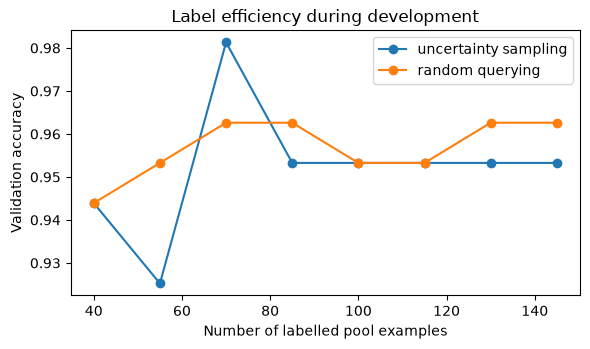

In [8]:
plt.figure(figsize=(6, 3.6))
plt.plot(label_counts, active_scores, marker="o", label="uncertainty sampling")
plt.plot(label_counts, random_scores, marker="o", label="random querying")
plt.xlabel("Number of labelled pool examples")
plt.ylabel("Validation accuracy")
plt.title("Label efficiency during development")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS / "label_efficiency_during_development.png", dpi=160, bbox_inches="tight")
plt.show()

**What to look for.** Both curves start at the same point and flatten within a few rounds, and uncertainty sampling does not pull clearly ahead. This dataset is simply too easy: 40 well-chosen labels already give a near-perfect linear model, so no policy has much left to gain. Active learning earns its keep where the boundary is genuinely uncertain.

Both policies are finished, so the test set is opened once for each.

In [9]:
active_idx, random_idx = sorted(active_labeled), sorted(random_labeled)
active_final = make_model().fit(X_pool.iloc[active_idx], y_pool[active_idx])
random_final = make_model().fit(X_pool.iloc[random_idx], y_pool[random_idx])
print("final test accuracy, uncertainty sampling:",
      round(accuracy_score(yc_test, active_final.predict(Xc_test)), 3))
print("final test accuracy, random querying:    ",
      round(accuracy_score(yc_test, random_final.predict(Xc_test)), 3))

final test accuracy, uncertainty sampling: 0.972
final test accuracy, random querying:     0.972


**What the output shows.** Self-training with 30% of the labels reaches 0.963. In the active-learning run both policies start at 0.944 with 40 labels and end at 0.972 on the test set; uncertainty sampling did **not** win, because this dataset is too easy for the policy to matter. The Try-it task starts from fewer labels to look for the regime where it does help.

## Evidence

Write the numbers above to the results folder. These files are regenerated on every run; do not edit them by hand.

In [10]:
pd.DataFrame([{"part": "A", "dataset": "credit_card_fraud", "model": "isolation_forest",
               "prevalence": prevalence, "roc_auc": roc_auc_score(y_test, anomaly_score),
               "average_precision": ap, f"precision_at_{review_budget}": top_k_precision},
              {"part": "B", "dataset": "breast_cancer", "model": "self_training (30% labels)",
               "validation_accuracy": accuracy_score(y_val, semi.predict(X_val))},
              {"part": "B", "dataset": "breast_cancer", "model": "active (uncertainty)",
               "test_accuracy": accuracy_score(yc_test, active_final.predict(Xc_test))},
              {"part": "B", "dataset": "breast_cancer", "model": "active (random)",
               "test_accuracy": accuracy_score(yc_test, random_final.predict(Xc_test))}]).round(4).to_csv(
    RESULTS / "metrics.csv", index=False)
ranked.head(review_budget).to_csv(RESULTS / "top_ranked_transactions.csv")
pd.DataFrame({"labels": label_counts, "uncertainty_sampling": active_scores,
              "random_querying": random_scores}).round(4).to_csv(RESULTS / "active_learning_curve.csv", index=False)
print("Saved:", sorted(p.name for p in RESULTS.iterdir()))

Saved: ['active_learning_curve.csv', 'label_efficiency_during_development.png', 'metrics.csv', 'precision_falls_as_the_review_budget_grows.png', 'top_ranked_transactions.csv']


## Try it yourself

Change the review budget in Part A to 50 and to 300 and report the fraud rate in each list. Then start the active-learning simulation from 10 labels per class instead of 20 and see whether uncertainty sampling pulls ahead.

Attempt it in the cell below before reading the solution.

In [11]:
# Your work here


### One solution

Two more review budgets, then the active-learning simulation restarted from 10 labels per class.

top  50 reviewed: fraud rate = 28.0%  (14 frauds found)
top 100 reviewed: fraud rate = 20.0%  (20 frauds found)
top 300 reviewed: fraud rate = 12.3%  (37 frauds found)


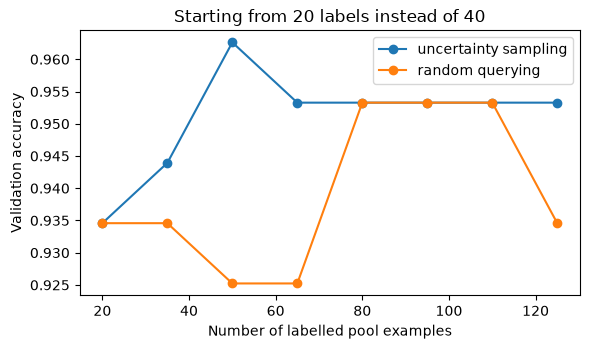

labels= 20  uncertainty=0.935  random=0.935
labels= 35  uncertainty=0.944  random=0.935
labels= 50  uncertainty=0.963  random=0.925
labels= 65  uncertainty=0.953  random=0.925
labels= 80  uncertainty=0.953  random=0.953
labels= 95  uncertainty=0.953  random=0.953
labels=110  uncertainty=0.953  random=0.953
labels=125  uncertainty=0.953  random=0.935


In [12]:
for budget in [50, 100, 300]:
    print(f"top {budget:3d} reviewed: fraud rate = {hits[:budget].mean():.1%}  ({int(hits[:budget].sum())} frauds found)")

def run_active_learning(n_per_class, rounds=8, query_batch=15, seed=42):
    r = np.random.default_rng(seed)
    r_random = np.random.default_rng(seed + 1)
    start = np.concatenate([r.choice(class0, n_per_class, replace=False),
                            r.choice(class1, n_per_class, replace=False)])
    active_set, random_set = set(start.tolist()), set(start.tolist())
    counts, act, rnd = [], [], []
    for round_no in range(rounds):
        a_idx, r_idx = sorted(active_set), sorted(random_set)
        a_model = make_model().fit(X_pool.iloc[a_idx], y_pool[a_idx])
        r_model = make_model().fit(X_pool.iloc[r_idx], y_pool[r_idx])
        counts.append(len(active_set))
        act.append(accuracy_score(y_val, a_model.predict(X_val)))
        rnd.append(accuracy_score(y_val, r_model.predict(X_val)))
        if round_no == rounds - 1:
            break
        unl = np.array([i for i in range(len(X_pool)) if i not in active_set])
        unc = np.abs(a_model.predict_proba(X_pool.iloc[unl])[:, 1] - 0.5)
        active_set.update(unl[np.argsort(unc)[:query_batch]].tolist())
        unl = np.array([i for i in range(len(X_pool)) if i not in random_set])
        random_set.update(r_random.choice(unl, query_batch, replace=False).tolist())
    return counts, act, rnd

counts10, act10, rnd10 = run_active_learning(n_per_class=10)
plt.figure(figsize=(6, 3.6))
plt.plot(counts10, act10, marker="o", label="uncertainty sampling")
plt.plot(counts10, rnd10, marker="o", label="random querying")
plt.xlabel("Number of labelled pool examples")
plt.ylabel("Validation accuracy")
plt.title("Starting from 20 labels instead of 40")
plt.legend()
plt.tight_layout()
plt.savefig(RESULTS / "active_learning_from_20_labels.png", dpi=160, bbox_inches="tight")
plt.show()
for c, a, r_ in zip(counts10, act10, rnd10):
    print(f"labels={c:3d}  uncertainty={a:.3f}  random={r_:.3f}")

**What it shows.** The fraud rate in the reviewed list falls as the budget grows: the top 50 are richer in fraud (28%) than the top 100 (20%), which are richer than the top 300 (12%). A team choosing a budget is choosing a point on that curve. Starting the active-learning simulation from only 20 labels makes the first rounds noisier, and now the two policies do separate for a few rounds before both saturate, because with so few labels the model's boundary is genuinely uncertain and asking about the uncertain cases fixes it faster than asking at random. Once either policy has a hundred or so labels the dataset is solved and the advantage disappears again.